1. 환경 설정 및 라이브러리 임포트

In [1]:
import datasets
from datasets import load_dataset, DatasetDict
from transformers import pipeline
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# GPU 사용 가능 여부 확인 및 설정
device = 0 if torch.cuda.is_available() else -1
print(f"사용 가능한 디바이스: {'GPU' if device == 0 else 'CPU'}")
# print(f"torch 버전: {torch.__version__}, datasets 버전: {datasets.__version__}")

사용 가능한 디바이스: GPU


In [2]:
# 데이터셋: KLUE MRC (기계 독해 데이터셋이지만, 기사 원문(context)을 활용)
DATASET_NAME = "klue"
SUBSET_NAME = "mrc"
NUM_SAMPLES = 100

# 1. KLUE MRC 데이터셋의 'train' split 로드
full_dataset = load_dataset(DATASET_NAME, SUBSET_NAME, split="train")

# 2. 실습을 위해 앞 100개 샘플만 선택하여 서브셋 생성
processing_subset = full_dataset.select(range(NUM_SAMPLES))

print(f"로드된 데이터셋 정보 (총 {NUM_SAMPLES}개 샘플):")
print(processing_subset)
print("\n첫 번째 데이터 예시 (context 확인):")
print(processing_subset[0]['context'][:150] + "...") # 원문 일부 출력

# 데이터셋 확인을 위해 Pandas DataFrame으로 변환
df_initial_check = pd.DataFrame(processing_subset)
# display(df_initial_check.head(3)) # Colab에서 확인용

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mrc/train-00000-of-00001.parquet:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

mrc/validation-00000-of-00001.parquet:   0%|          | 0.00/8.68M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17554 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5841 [00:00<?, ? examples/s]

로드된 데이터셋 정보 (총 100개 샘플):
Dataset({
    features: ['title', 'context', 'news_category', 'source', 'guid', 'is_impossible', 'question_type', 'question', 'answers'],
    num_rows: 100
})

첫 번째 데이터 예시 (context 확인):
올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도 늦은 이달 말께 장마가 시작될 전망이다.17일 기상청에 따르면 제주도 남쪽 먼바다에 있는 장마전선의 영향으로 이날 제주도 산간 및 내륙지역에 호우주의보가 내려지면서 곳곳에 100㎜에 육...


In [3]:

# 모델: gogamza/kobart-summarization (BART 기반 한국어 요약 모델)
summarizer = pipeline(
    task="summarization",
    model="gogamza/kobart-summarization",
    device=device
)
print("요약 파이프라인 로드 완료.")

def summarize_context(example):
    """'context'를 요약하고 'summary' 컬럼에 추가"""
    summary_result = summarizer(
        example['context'],
        max_length=120, # 최대 길이 제한
        min_length=20,
        do_sample=False # 확정적(deterministic) 결과
    )
    example['summary'] = summary_result[0]['summary_text']
    return example

# 데이터셋에 적용
processing_subset = processing_subset.map(summarize_context)
print("\n요약 작업 완료.")

config.json: 0.00B [00:00, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


vocab.json: 0.00B [00:00, ?B/s]

...

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
Device set to use cuda:0


요약 파이프라인 로드 완료.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



요약 작업 완료.


In [6]:
# @title 3.2. 번역 파이프라인 로드 및 적용
# 모델: facebook/nllb-200-distilled-600M (다국어 번역 모델)
translator = pipeline(
    task="translation",
    model="facebook/nllb-200-distilled-600M",
    device=device
)
print("번역 파이프라인 로드 완료.")

def translate_summary_to_english(example):
    """'summary'를 영어로 번역하고 'english_summary' 컬럼에 추가"""
    translation_result = translator(
        example['summary'],
        src_lang="kor_Hang", # 한국어
        tgt_lang="eng_Latn", # 영어
        max_length=400
    )
    example['english_summary'] = translation_result[0]['translation_text']
    return example

# 데이터셋에 적용
processing_subset = processing_subset.map(translate_summary_to_english)
print("\n번역 작업 완료.")

Device set to use cuda:0


번역 파이프라인 로드 완료.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]


번역 작업 완료.


In [7]:
# @title 3.3. 감정 분석 파이프라인 로드 및 적용
# 모델: SamLowe/roberta-base-go_emotions (영어 감정 분류 모델)
emotion_classifier = pipeline(
    task="text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=1, # 가장 확률 높은 감정 1개만 반환
    device=device
)
print("감정 분석 파이프라인 로드 완료.")

def analyze_emotion(example):
    """'english_summary'의 감정을 분석하고 'emotion' 컬럼에 추가"""
    # 감정 분석 파이프라인은 텍스트를 리스트 형태로 받으므로, 입력 텍스트를 리스트로 감싸야 합니다.
    emotion_result = emotion_classifier(example['english_summary'])
    # top_k=1 옵션으로 인해 결과는 [[{'label': '...', 'score': ...}]] 형태
    example['emotion'] = emotion_result[0][0]['label']
    example['emotion_score'] = emotion_result[0][0]['score'] # 점수도 함께 저장
    return example

# 데이터셋에 적용
final_dataset = processing_subset.map(analyze_emotion)
print("\n감정 분석 작업 완료.")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Device set to use cuda:0


감정 분석 파이프라인 로드 완료.


Map:   0%|          | 0/100 [00:00<?, ? examples/s]


감정 분석 작업 완료.


--- 최종 결과 데이터셋 (3개 샘플) ---


/tmp/ipython-input-194645171.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final_preview['context'] = df_final_preview['context'].apply(lambda x: x[:70] + '...')


,context,summary,english_summary,emotion,emotion_score
0,올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도...,올여름 장마가 17일 제주도에서 시작되었으며 서울 등 중부지방은 예년보다 사나흘 정...,All-summer festivals began on the 17th in Jeju...,neutral,0.712235
1,부산시와 (재)부산정보산업진흥원(원장 이인숙)이 ‘2020~2021년 지역SW서비스...,‘2020~2021년 지역SW서비스사업화 지원사업’ 공모사업에 부산의 4개 과제가 ...,"In the years 2020-2021, four projects of the s...",neutral,0.769332
2,부산시와 (재)부산정보산업진흥원(원장 이인숙)이 ‘2020~2021년 지역SW서비스...,‘2020~2021년 지역SW서비스사업화 지원사업’ 공모사업에 부산의 4개 과제가 ...,"In the years 2020-2021, four projects of the s...",neutral,0.769332



--- 샘플 1 ---
원문 일부: 올여름 장마가 17일 제주도에서 시작됐다. 서울 등 중부지방은 예년보다 사나흘 정도 늦은 이달 말께 장마가 시작될 전망이다.1...
요약: 올여름 장마가 17일 제주도에서 시작되었으며 서울 등 중부지방은 예년보다 사나흘 정도 늦은 이달 말께 장마가 시작될 전망이다.
영어 번역: All-summer festivals began on the 17th in Jeju, and in central regions such as Seoul, the festival is expected to begin at the end of this month, which is about three days later than last year.
분석 감정: neutral (Score: 0.7122)

--- 샘플 2 ---
원문 일부: 부산시와 (재)부산정보산업진흥원(원장 이인숙)이 ‘2020~2021년 지역SW서비스사업화 지원사업’ 공모사업에 4개 과제가 선...
요약: ‘2020~2021년 지역SW서비스사업화 지원사업’ 공모사업에 부산의 4개 과제가 최종 선정되는 쾌거를 거뒀다.
영어 번역: In the years 2020-2021, four projects of the sector were selected for regional SW service entrepreneurial support projects.
분석 감정: neutral (Score: 0.7693)

--- 샘플 3 ---
원문 일부: 부산시와 (재)부산정보산업진흥원(원장 이인숙)이 ‘2020~2021년 지역SW서비스사업화 지원사업’ 공모사업에 4개 과제가 선...
요약: ‘2020~2021년 지역SW서비스사업화 지원사업’ 공모사업에 부산의 4개 과제가 최종 선정되는 쾌거를 거뒀다.
영어 번역: In the years 2020-2021, four projects of the sector were selected for regional SW service entrepreneurial

/tmp/ipython-input-194645171.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='emotion', data=df_final, order=df_final['emotion'].value_counts().index, palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: 

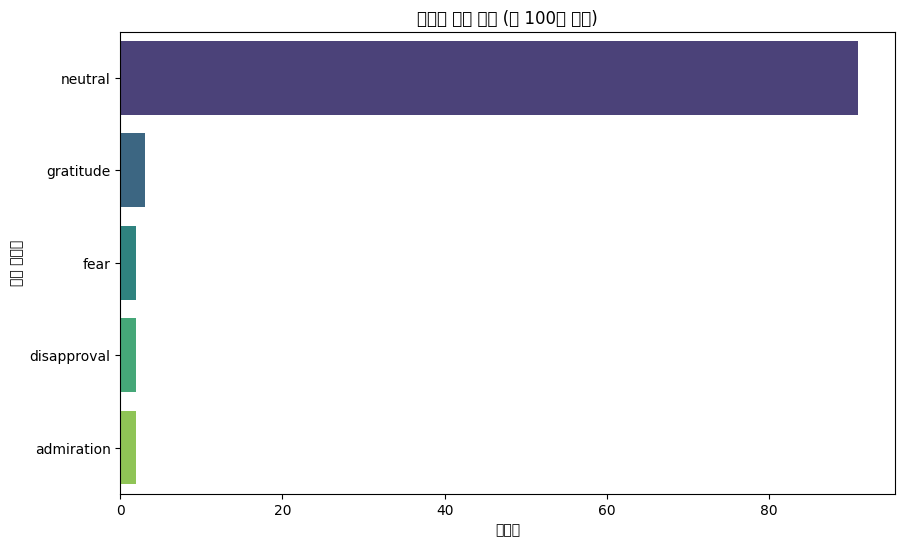


감정 분석 결과 시각화 준비 완료. 


In [9]:
# @title 5. 결과 분석 및 확인
print("--- 최종 결과 데이터셋 (3개 샘플) ---")
df_final = pd.DataFrame(final_dataset)

# 필요한 컬럼만 선택하여 출력
columns_to_show = ['context', 'summary', 'english_summary', 'emotion', 'emotion_score']
df_final_preview = df_final[columns_to_show]

# 원문은 너무 길 수 있으므로 줄여서 출력
df_final_preview['context'] = df_final_preview['context'].apply(lambda x: x[:70] + '...')

display(df_final_preview.head(3)) # Colab에서 확인용

# 최종 결과 확인 (첫 3개 샘플)
for i in range(min(3, len(final_dataset))):
    print(f"\n--- 샘플 {i+1} ---")
    print(f"원문 일부: {final_dataset[i]['context'][:70]}...")
    print(f"요약: {final_dataset[i]['summary']}")
    print(f"영어 번역: {final_dataset[i]['english_summary']}")
    print(f"분석 감정: {final_dataset[i]['emotion']} (Score: {final_dataset[i]['emotion_score']:.4f})")

# 6. 시각화 (감정 비율 그래프)
plt.figure(figsize=(10, 6))
sns.countplot(y='emotion', data=df_final, order=df_final['emotion'].value_counts().index, palette='viridis')
plt.title(f'분석된 감정 분포 (총 {NUM_SAMPLES}개 샘플)')
plt.xlabel('빈도수')
plt.ylabel('감정 레이블')
plt.show() # Colab에서 확인용
print("\n감정 분석 결과 시각화 준비 완료. ")